In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
import os
os.getcwd()

'C:\\Users\\Dell\\Downloads'

In [25]:
df=pd.read_csv(r"C:\Users\Dell\retail_sales_dataset.csv")
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [26]:
df.shape                      #check the shape of the dataset

(1000, 9)

In [27]:
df.dtypes                   #check data types

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [28]:
df.columns                 #check column names

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [29]:
df.duplicated().sum()              #check duplicate rows

np.int64(0)

In [30]:
df.isnull().sum()              #check missing values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [31]:
#identify numerical columns
numerical_columns=df.select_dtypes(include=['int64','float64']).columns
print("Numerical columns:", numerical_columns)

Numerical columns: Index(['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount'], dtype='object')


In [32]:
#Basic descriptive statistics
df[numerical_columns].describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [33]:

print(df[numerical_columns].mean())            #calculate mean

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


In [34]:
print(df[numerical_columns].median())  #calculate median

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64


In [35]:
print(df[numerical_columns].mode().iloc[0])        #calculate mode

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


In [61]:
print(df[numerical_columns].std())              #Standard deviation

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [36]:
#Create summary table
summary=pd.DataFrame({"Mean":df[numerical_columns].mean() ,                 
                      "Median":df[numerical_columns].median(),
                      "Mode":df[numerical_columns].mode().iloc[0],
                      "Standard deviation":df[numerical_columns].std()})
summary

,Mean,Median,Mode,Standard deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [37]:
df["Date"]=pd.to_datetime(df["Date"])              #convert date column to datetime

In [38]:
df["Month"]=df["Date"].dt.to_period("M")
df["Quarter"]=df["Date"].dt.to_period("Q")       #create month and quarter columns

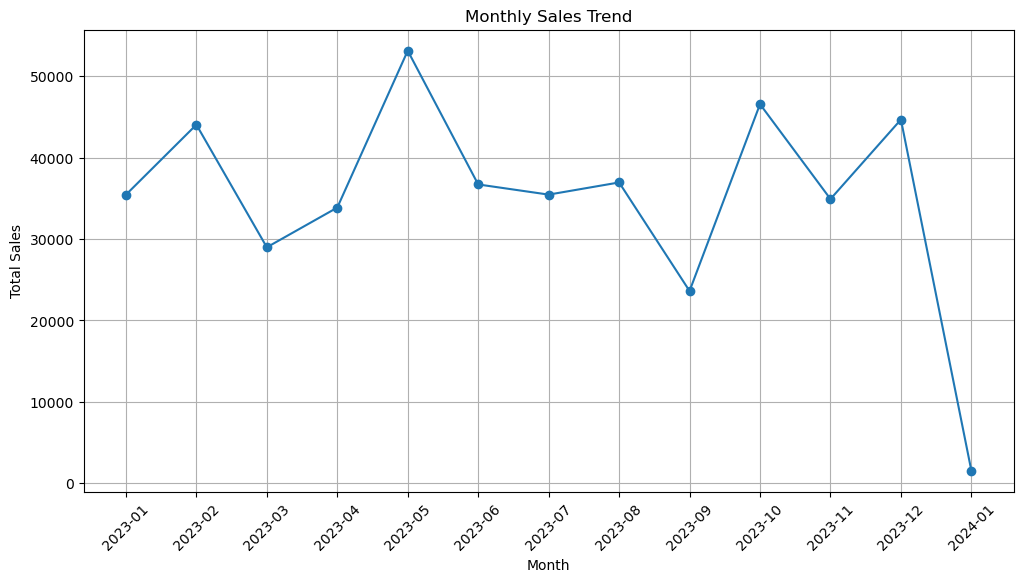

In [39]:
#monthly sales trend

monthly_sales=df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Observation

- The monthly sales trend shows how total sales vary across different months.
- Peak months indicate periods of higher customer demand, while low-sales months may require promotional strategies.
- Any recurring peaks or dips may suggest seasonal purchasing patterns.

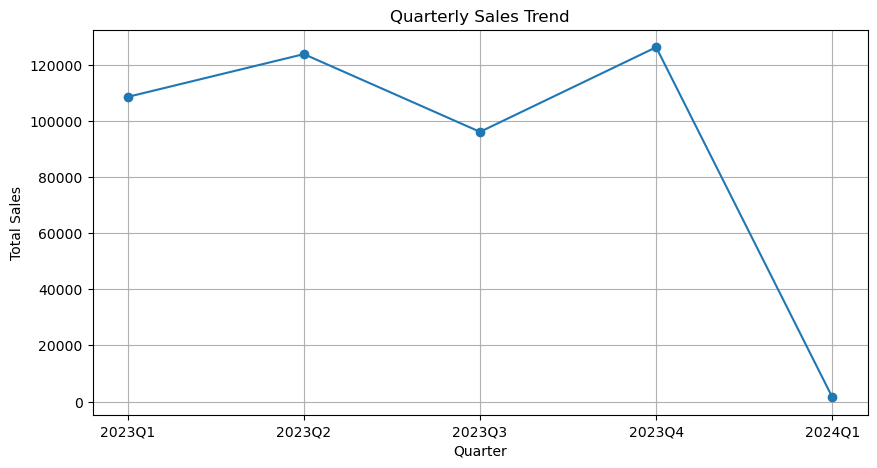

In [40]:
#Quarterly sales trend

quarterly_sales=df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(10,5))
plt.plot(quarterly_sales.index.astype(str),quarterly_sales.values,marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

## Observation

- The quarterly sales trend summarizes business performance every three months.
- Comparing quarters helps identify the strongest and weakest sales periods.
- This analysis can support inventory planning, budgeting, and marketing decisions.


In [41]:
print(df["Gender"].unique())

['Male' 'Female']


In [42]:
#Create age groups

bins=[0,18,25,35,45,55,100]
labels=["<18","18-25","26-35","36-45","46-55","55+"]
df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

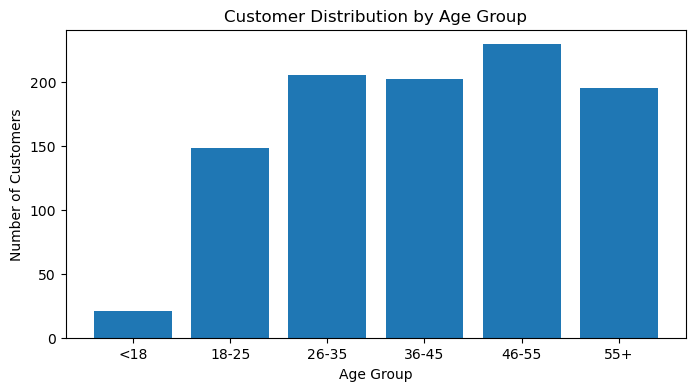

In [43]:
#Plot Age Group Distribution

age_group_counts=df["Age Group"].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(age_group_counts.index.astype(str),age_group_counts.values)
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.show()

## Observation

- The chart shows the distribution of customers across different age groups.
- The age group with the highest number of customers represents the primary target audience.
- Businesses can use this information to design age-specific marketing campaigns and product recommendations.

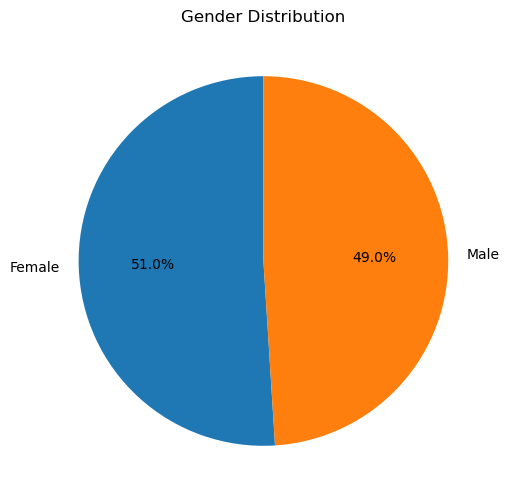

In [44]:
#Gender Distribution

gender_counts=df["Gender"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_counts.values,labels=gender_counts.index,
        autopct="%1.1f%%",startangle=90)
plt.title("Gender Distribution")
plt.show()


## Observation

- The pie chart shows the proportion of male and female customers.
- If one gender contributes a larger share of customers, businesses can tailor marketing strategies and promotions accordingly.
- A balanced gender distribution indicates that products appeal to a broad customer base.

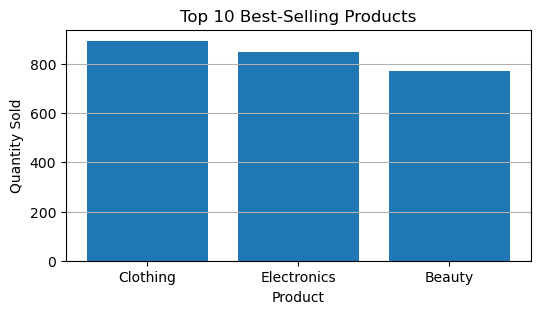

In [53]:
#Top 10 Best selling products

top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,3))
plt.bar(top_products.index, top_products.values)
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.grid(axis="y")
plt.show()

## Observation

- The chart displays the top 10 best-selling products based on the total quantity sold.
- The highest-selling products are the most popular among customers and contribute significantly to overall sales.
- These products should be prioritized for inventory management and promotional campaigns.
- Lower-selling products may require marketing efforts or pricing adjustments to improve performance.

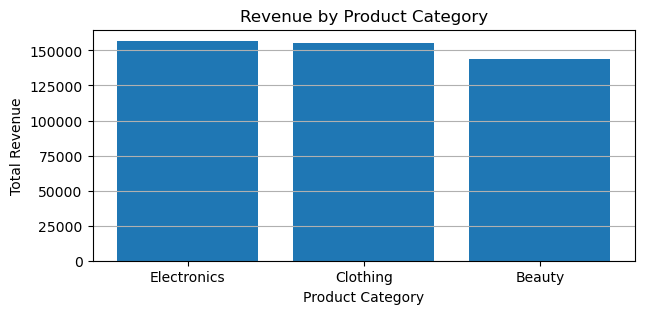

In [55]:
#Revenue by product category

category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,3))
plt.bar(category_revenue.index, category_revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.grid(axis="y")
plt.show()

## Observation

- The bar chart illustrates the total revenue generated by each product category.
- The category with the highest revenue is the strongest contributor to overall sales and should be prioritized for inventory and marketing efforts.
- Categories with lower revenue may require promotional campaigns, discounts, or product improvements to increase sales.
- This analysis helps identify the most profitable product categories and supports better business decision-making.

In [56]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

In [57]:
correlation_matrix = numerical_df.corr()
correlation_matrix

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


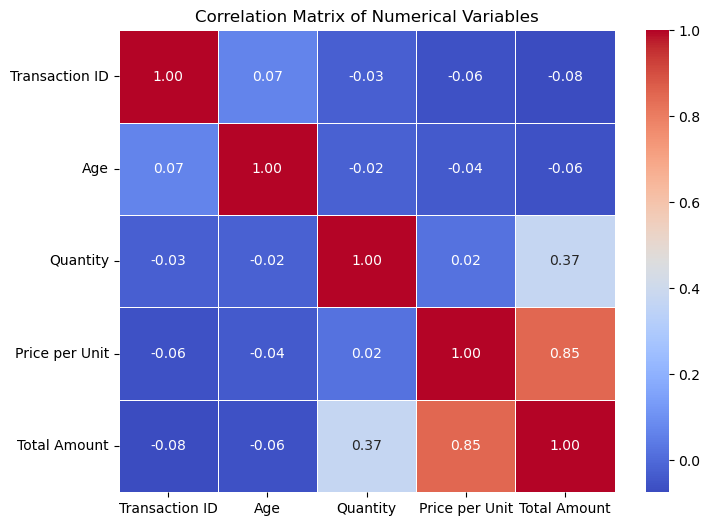

In [58]:
#plot heatmap

plt.figure(figsize=(8,6))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

## Observation

- The heatmap displays the correlation between all numerical variables in the dataset.
- Correlation values range from **-1 to +1**, where:
  - **+1** indicates a perfect positive correlation.
  - **-1** indicates a perfect negative correlation.
  - **0** indicates no correlation.
- A strong positive correlation suggests that as one variable increases, the other also tends to increase.
- Variables with weak or no correlation have little linear relationship.
- This analysis helps identify relationships between variables and can support feature selection for predictive models.

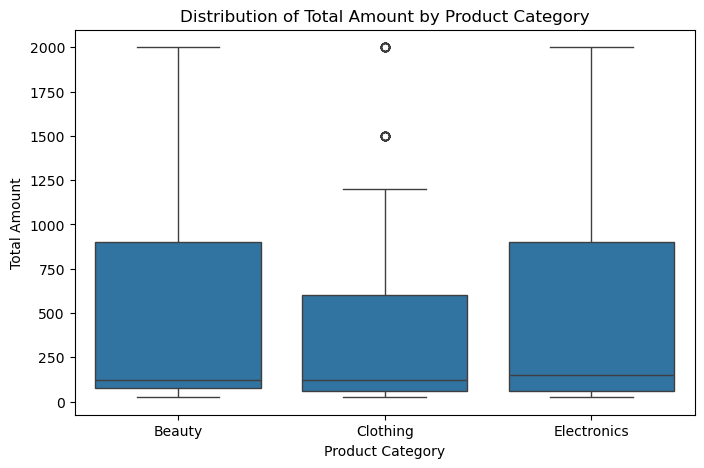

In [60]:
# Additional visualization 
#Box plot of total amount by product category

plt.figure(figsize=(8,5))

sns.boxplot(x="Product Category", y="Total Amount", data=df)

plt.title("Distribution of Total Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.show()

## Observation

- The box plot shows the distribution of transaction amounts across different product categories.
- Categories with a wider spread indicate greater variability in customer spending.
- Outliers represent unusually high-value transactions, which may correspond to premium products or bulk purchases.
- This visualization helps identify which product categories have consistent sales and which experience occasional high-value purchases.

# Conclusion and Business Recommendations

## Key Findings

- Customer purchasing behavior varies across different product categories.
- Certain product categories generate significantly higher revenue than others.
- Monthly and quarterly sales trends help identify periods of high and low demand.
- Customer demographics reveal the primary target audience.

## Business Recommendations

1. **Prioritize high-performing product categories** by maintaining sufficient inventory and running targeted marketing campaigns.

2. **Increase sales in low-performing categories** through discounts, product bundles, or promotional offers.

3. **Use seasonal sales trends** to plan inventory, staffing, and marketing campaigns during high-demand periods.

4. **Develop targeted marketing campaigns** based on customer age groups and gender to improve customer engagement and sales.

5. **Monitor high-value transactions** to identify premium customers and create loyalty or reward programs for them.